In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import nltk
import re
import inflect
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [5]:
df = pd.read_csv('emails.csv')
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [6]:
df.shape

(5728, 2)

In [7]:
df.dtypes

text    object
spam     int64
dtype: object

In [8]:
df.isnull().sum()

text    0
spam    0
dtype: int64

In [9]:
df.duplicated().sum()

33

In [10]:
df = df.drop_duplicates(keep = 'first')
df.duplicated().sum()

0

In [11]:
df['spam'].value_counts()

spam
0    4327
1    1368
Name: count, dtype: int64

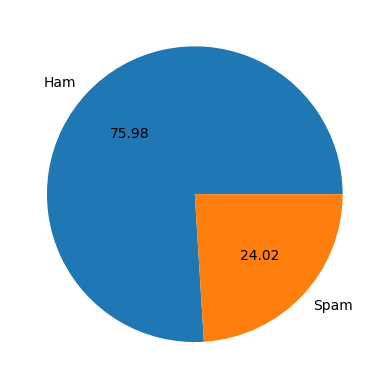

In [12]:
plt.pie(df.spam.value_counts(), autopct = '%0.2f', labels = ['Ham', 'Spam'])
plt.show()

In [13]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rushikesh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Rushikesh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Rushikesh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [14]:
def transform_text(text):
    text = text.lower()
    text = re.sub(r'[^A-Za-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = nltk.word_tokenize(text)
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))
    lemma = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words]
    cleaned_text= [inflect.engine().number_to_words(token) if token.isdigit() else token for token in lemma]
    return ' '.join(cleaned_text)

In [15]:

df['preprocessed_text'] = df.text.apply(transform_text)
df.head()

,text,spam,preprocessed_text
0,Subject: naturally irresistible your corporate...,1,subject naturally irresistible corporate ident...
1,Subject: the stock trading gunslinger fanny i...,1,subject stock trading gunslinger fanny merrill...
2,Subject: unbelievable new homes made easy im ...,1,subject unbelievable new home made easy im wan...
3,Subject: 4 color printing special request add...,1,subject four color printing special request ad...
4,"Subject: do not have money , get software cds ...",1,subject money get software cd software compati...


In [16]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['spam']=encoder.fit_transform(df['spam'])

In [17]:
from wordcloud import WordCloud
wc = WordCloud()

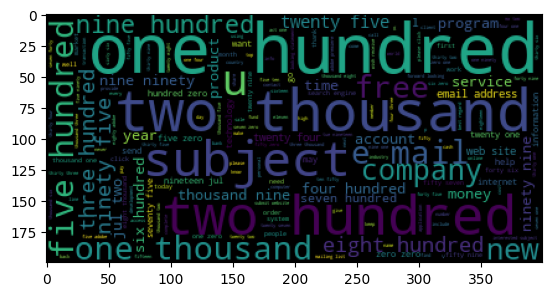

In [18]:
spam_wc = wc.generate(" ".join(df[df.spam == 1]['preprocessed_text']))
plt.imshow(spam_wc)

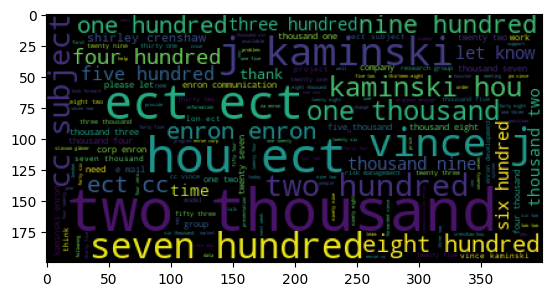

In [19]:
ham_wc = wc.generate(" ".join(df[df.spam == 0]['preprocessed_text']))
plt.imshow(ham_wc)

## Model Building

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df.preprocessed_text).toarray()
y = df.spam.values

In [21]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)

In [22]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [23]:
gnb = GaussianNB()
mnb = MultinomialNB()

In [24]:
gnb.fit(x_train, y_train)
y_pred_gnb = gnb.predict(x_test)
print(accuracy_score(y_test, y_pred_gnb))
print(classification_report(y_test,y_pred_gnb))
print(confusion_matrix(y_test,y_pred_gnb))


0.9473404255319149
              precision    recall  f1-score   support

           0       0.94      0.99      0.97      1390
           1       0.97      0.83      0.89       490

    accuracy                           0.95      1880
   macro avg       0.95      0.91      0.93      1880
weighted avg       0.95      0.95      0.95      1880

[[1376   14]
 [  85  405]]


In [25]:
mnb.fit(x_train, y_train)
y_pred_mnb = gnb.predict(x_test)
print(accuracy_score(y_test, y_pred_gnb))
print(classification_report(y_test,y_pred_mnb))
print(confusion_matrix(y_test,y_pred_mnb))

0.9473404255319149
              precision    recall  f1-score   support

           0       0.94      0.99      0.97      1390
           1       0.97      0.83      0.89       490

    accuracy                           0.95      1880
   macro avg       0.95      0.91      0.93      1880
weighted avg       0.95      0.95      0.95      1880

[[1376   14]
 [  85  405]]


In [26]:
from sklearn.linear_model import LogisticRegression
log = LogisticRegression()
log.fit(x_train, y_train)
y_pred = log.predict(x_test)
accuracy_score(y_test, y_pred)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1390
           1       0.99      0.89      0.94       490

    accuracy                           0.97      1880
   macro avg       0.98      0.94      0.96      1880
weighted avg       0.97      0.97      0.97      1880

[[1385    5]
 [  55  435]]


In [42]:
def predict_spam_or_ham(model, vectorizer, message):
    cleaned_message = transform_text(message)
    message_vector = vectorizer.transform([cleaned_message]).toarray()
    prediction = model.predict(message_vector)
    return "Spam" if prediction[0] == 1 else "Ham"

In [43]:
message = "Congratulations! You've won a $1000 Walmart gift card. Click here to claim your prize: www.fakeprize.com"
predict_spam_or_ham(gnb, tfidf, message)

'Spam'